## Mashiur Rahman

### Assignment 8: Supervised Learning Classification

## 1. Dataset Selection and Preprocessing

### Titanic Survival Classification Project

### 1. Dataset Selection and Preprocessing

The Titanic dataset is a publicly available classification dataset. The purpose of this project is to predict whether a passenger survived the Titanic disaster.

The target variable is survived:

- 0 = Did not survive
- 1 = Survived

#### Import libraries

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings

warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    RocCurveDisplay
)

sns.set_style("whitegrid")

#### Load the dataset

In [2]:
# Load the Titanic dataset from a public source
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv"
df = pd.read_csv(url)

# Display the first five rows
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


#### Examine the dataset

In [3]:
print("Dataset shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

print("\nDataset information:")
df.info()

Dataset shape: (891, 15)

Column names:
['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    str    
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    str    
 8   class        891 non-null    str    
 9   who          891 non-null    str    
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    str    
 12  embark_town  889 non-null    str    
 13  alive        891 non-null    str    
 14  alone        891 non-

#### Select relevant columns

In [4]:
# Select useful features and the target variable
selected_columns = [
    "survived",
    "pclass",
    "sex",
    "age",
    "sibsp",
    "parch",
    "fare",
    "embarked",
    "class",
    "who",
    "alone"
]

data = df[selected_columns].copy()

data.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True


#### Check missing values and duplicates

In [5]:
print("Missing values:")
print(data.isnull().sum())

print("\nNumber of duplicate rows:")
print(data.duplicated().sum())

Missing values:
survived      0
pclass        0
sex           0
age         177
sibsp         0
parch         0
fare          0
embarked      2
class         0
who           0
alone         0
dtype: int64

Number of duplicate rows:
111


#### Remove duplicates

In [6]:
# Remove duplicate records
data = data.drop_duplicates().reset_index(drop=True)

print("Dataset shape after removing duplicates:", data.shape)

Dataset shape after removing duplicates: (780, 11)


## 2. Exploratory Data Analysis (EDA)

Exploratory Data Analysis is performed to understand the distribution of the target variable, examine numerical variables, identify relationships between features, and discover patterns that may influence passenger survival.

#### Descriptive statistics

In [7]:
# Summary statistics for numerical columns
data.describe()

,survived,pclass,age,sibsp,parch,fare
count,780.000000,780.000000,676.000000,780.000000,780.000000,780.000000
mean,0.412821,2.246154,29.812751,0.525641,0.417949,34.829108
std,0.492657,0.854452,14.727098,0.988046,0.838536,52.263440
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,20.000000,0.000000,0.000000,8.050000
50%,0.000000,3.000000,28.000000,0.000000,0.000000,15.950000
75%,1.000000,3.000000,39.000000,1.000000,1.000000,34.375000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


#### Class distribution

survived
0    458
1    322
Name: count, dtype: int64


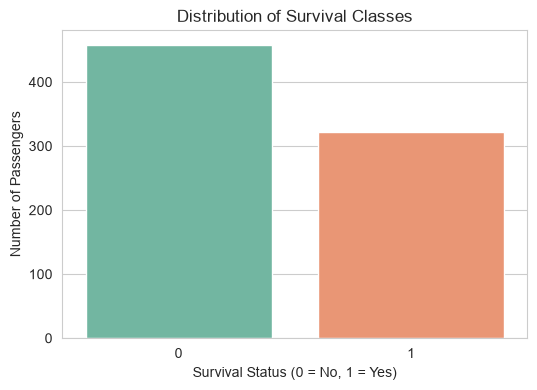

In [8]:
# Display the number of passengers in each survival class
print(data["survived"].value_counts())

# Visualize the class distribution
plt.figure(figsize=(6, 4))

sns.countplot(
    data=data,
    x="survived",
    hue="survived",
    palette="Set2",
    legend=False
)

plt.title("Distribution of Survival Classes")
plt.xlabel("Survival Status (0 = No, 1 = Yes)")
plt.ylabel("Number of Passengers")
plt.show()

#### Class distribution percentages

In [9]:
survival_percentage = (
    data["survived"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
)

print("Survival class percentages:")
print(survival_percentage.round(2))

Survival class percentages:
survived
0    58.72
1    41.28
Name: proportion, dtype: float64


#### Correlation heatmap

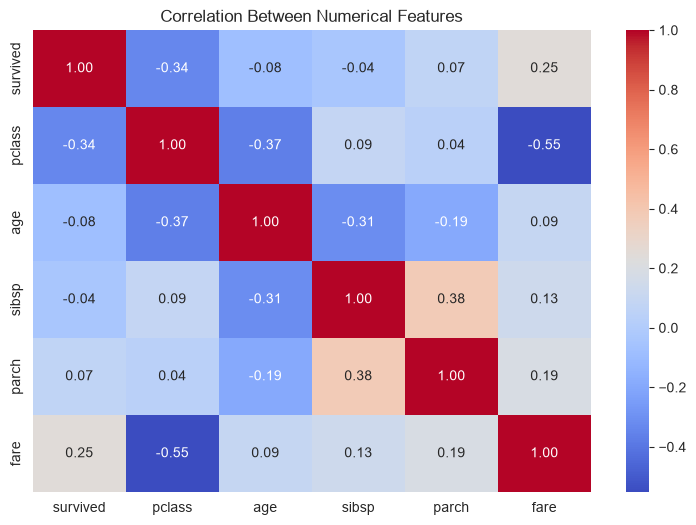

In [10]:
# Select numerical variables
numeric_data = data.select_dtypes(include=np.number)

# Calculate correlations
correlation_matrix = numeric_data.corr()

plt.figure(figsize=(9, 6))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Between Numerical Features")
plt.show()

#### Survival by gender

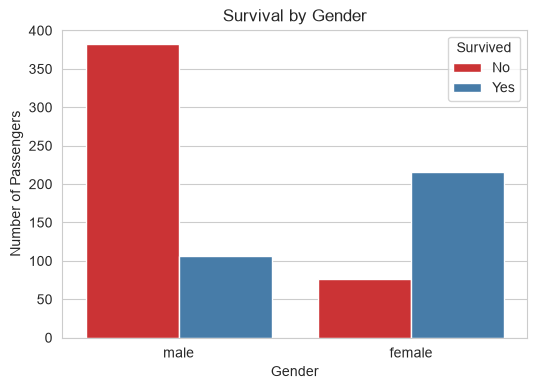

In [11]:
plt.figure(figsize=(6, 4))

sns.countplot(
    data=data,
    x="sex",
    hue="survived",
    palette="Set1"
)

plt.title("Survival by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Passengers")
plt.legend(title="Survived", labels=["No", "Yes"])
plt.show()

#### Survival by passenger class

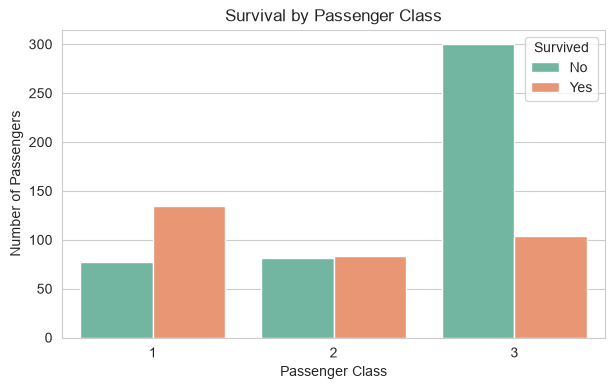

In [12]:
plt.figure(figsize=(7, 4))

sns.countplot(
    data=data,
    x="pclass",
    hue="survived",
    palette="Set2"
)

plt.title("Survival by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")
plt.legend(title="Survived", labels=["No", "Yes"])
plt.show()

#### Age distribution

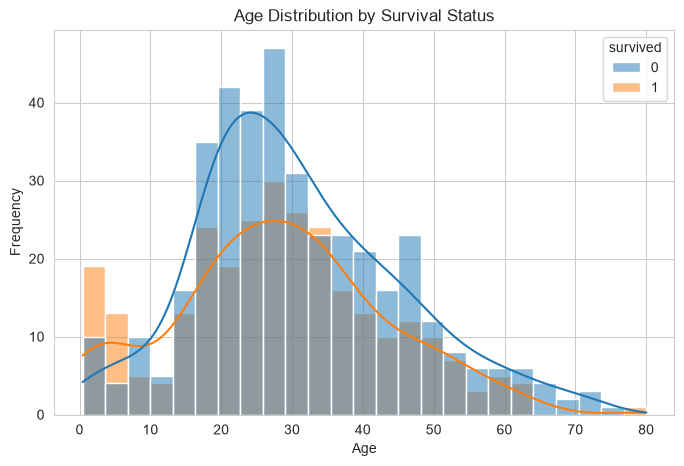

In [13]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=data,
    x="age",
    hue="survived",
    bins=25,
    kde=True,
    multiple="layer"
)

plt.title("Age Distribution by Survival Status")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

#### EDA findings

- The dataset contains more passengers who did not survive survive than passengers who survived.
- Female passengers had a higher survival rate than male passengers.
- First-class passengers had a higher survival rate than third-class passengers.
- Passenger class, gender, age, and fare appear to be important predictors.
- Because the target contains only two outcomes, this is a binary classification problem.

## 3. Model Implementation and Evaluation

Three classification algorithms are implemented and compared:

1. Logistic Regression
2. Decision Tree Classifier
3. Random Forest Classifier

The models are evaluated using accuracy, precision, recall, F1-score, and ROC-AUC score.

#### Define features and target

In [14]:
# Separate independent variables and target variable
X = data.drop("survived", axis=1)
y = data["survived"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (780, 10)
Target shape: (780,)


#### Identify numerical and categorical columns

In [15]:
numerical_features = [
    "pclass",
    "age",
    "sibsp",
    "parch",
    "fare"
]

categorical_features = [
    "sex",
    "embarked",
    "class",
    "who",
    "alone"
]

print("Numerical features:", numerical_features)
print("Categorical features:", categorical_features)

Numerical features: ['pclass', 'age', 'sibsp', 'parch', 'fare']
Categorical features: ['sex', 'embarked', 'class', 'who', 'alone']


#### Create preprocessing pipelines

In [16]:
# Numerical preprocessing
numerical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical preprocessing
categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

# Combine numerical and categorical preprocessing
preprocessor = ColumnTransformer(transformers=[
    ("numerical", numerical_pipeline, numerical_features),
    ("categorical", categorical_pipeline, categorical_features)
])

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


#### Split training and testing data

In [17]:
# Split the dataset into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (624, 10)
Testing set size: (156, 10)


#### Create models

In [18]:
# Define the classification models
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),
    
    "Decision Tree": DecisionTreeClassifier(
        max_depth=5,
        random_state=42
    ),
    
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=7,
        random_state=42
    )
}

models

{'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
 'Decision Tree': DecisionTreeClassifier(max_depth=5, random_state=42),
 'Random Forest': RandomForestClassifier(max_depth=7, n_estimators=200, random_state=42)}

#### Train and evaluate models

In [19]:
results = []
trained_models = {}

for model_name, classifier in models.items():
    
    # Create a complete preprocessing and model pipeline
    model_pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", classifier)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Make predictions
    y_pred = model_pipeline.predict(X_test)
    y_probability = model_pipeline.predict_proba(X_test)[:, 1]
    
    # Calculate evaluation metrics
    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_probability)
    })
    
    trained_models[model_name] = model_pipeline

# Convert results into a DataFrame
results_df = pd.DataFrame(results)

# Sort from highest to lowest ROC-AUC score
results_df = results_df.sort_values(
    by="ROC-AUC",
    ascending=False
).reset_index(drop=True)

results_df.round(3)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.827,0.814,0.750,0.780,0.894
1,Random Forest,0.801,0.884,0.594,0.710,0.855
2,Decision Tree,0.827,0.849,0.703,0.769,0.844


#### Compare model performance

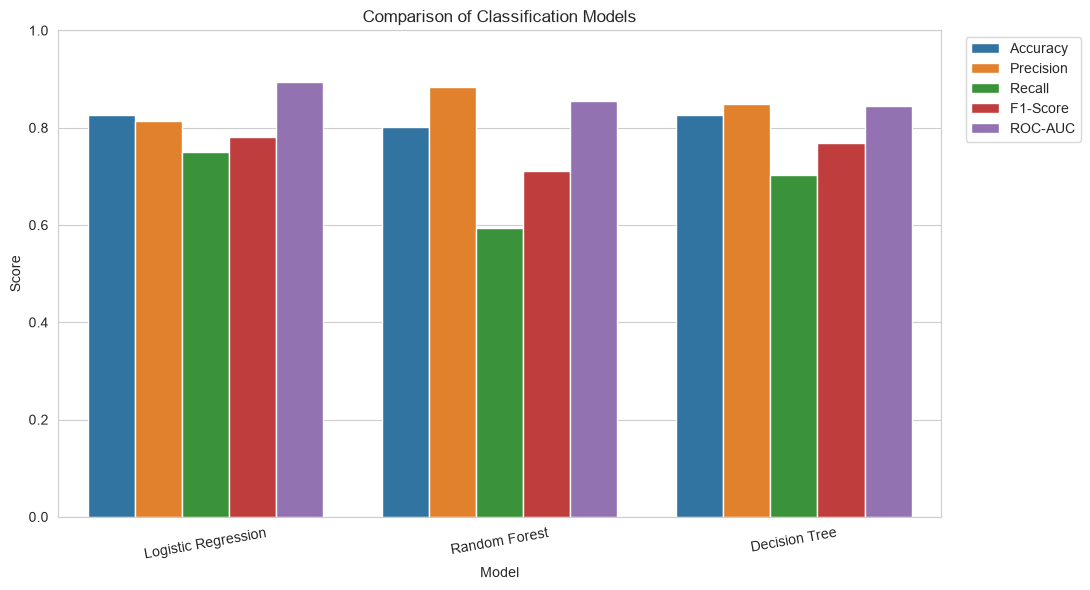

In [20]:
results_long = results_df.melt(
    id_vars="Model",
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(11, 6))

sns.barplot(
    data=results_long,
    x="Model",
    y="Score",
    hue="Metric"
)

plt.title("Comparison of Classification Models")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=10)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

#### Select the best model

In [21]:
# Select the model with the highest ROC-AUC score
best_model_name = results_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]

print("Best-performing model:", best_model_name)
print("\nBest model results:")
display(results_df.iloc[[0]].round(3))

Best-performing model: Logistic Regression

Best model results:


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.827,0.814,0.75,0.78,0.894


#### Classification report

In [22]:
# Make predictions using the best model
best_predictions = best_model.predict(X_test)

print("Classification Report for", best_model_name)
print(classification_report(
    y_test,
    best_predictions,
    target_names=["Did Not Survive", "Survived"]
))

Classification Report for Logistic Regression
                 precision    recall  f1-score   support

Did Not Survive       0.84      0.88      0.86        92
       Survived       0.81      0.75      0.78        64

       accuracy                           0.83       156
      macro avg       0.82      0.82      0.82       156
   weighted avg       0.83      0.83      0.83       156



## 4. Model Interpretation and Inference

The best-performing model is selected using the ROC-AUC score. Accuracy measures the overall percentage of correct predictions.
Precision measures how many predicted survivors actually survived. Recall measures how many actual survivors were correctly identified.
The F1-score provides a balance between precision and recall.

#### Confusion matrix

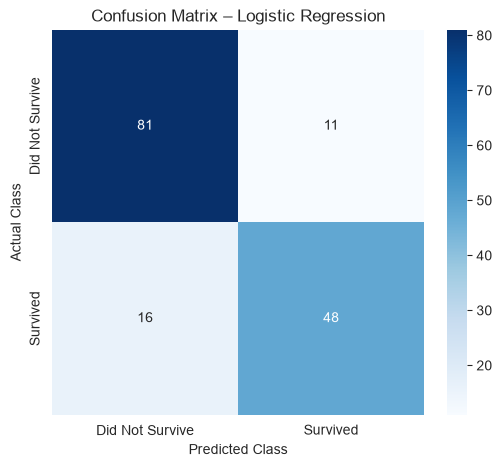

In [23]:
# Calculate the confusion matrix
cm = confusion_matrix(y_test, best_predictions)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Did Not Survive", "Survived"],
    yticklabels=["Did Not Survive", "Survived"]
)

plt.title(f"Confusion Matrix – {best_model_name}")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.show()

#### ROC curves

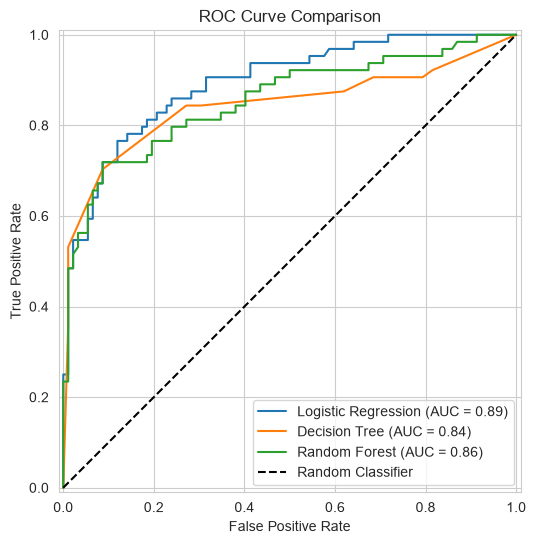

In [24]:
plt.figure(figsize=(8, 6))

for model_name, model_pipeline in trained_models.items():
    RocCurveDisplay.from_estimator(
        model_pipeline,
        X_test,
        y_test,
        name=model_name,
        ax=plt.gca()
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="black",
    label="Random Classifier"
)

plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

#### Feature importance

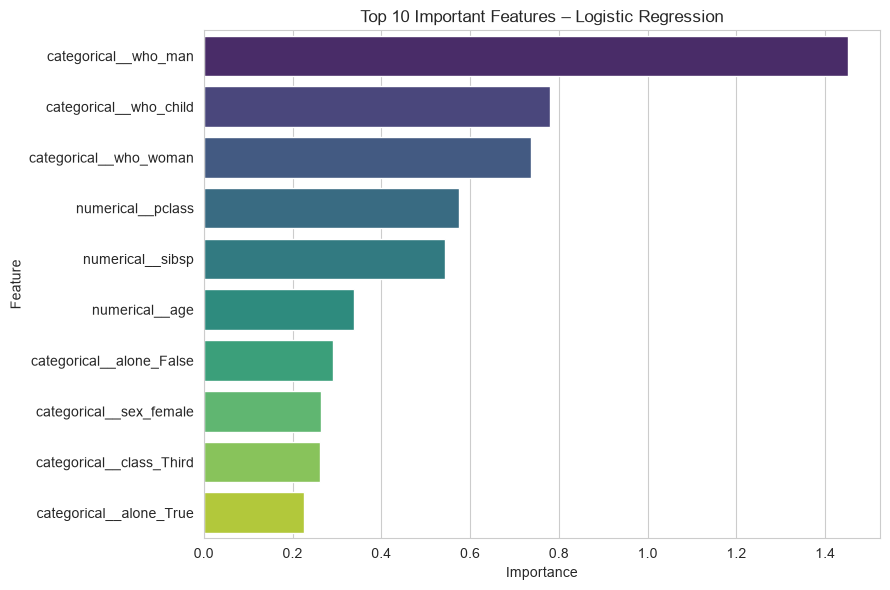

In [25]:
# Get feature names after preprocessing
feature_names = best_model.named_steps[
    "preprocessor"
].get_feature_names_out()

classifier = best_model.named_steps["classifier"]

# Get feature importance or coefficient values
if hasattr(classifier, "feature_importances_"):
    importance_values = classifier.feature_importances_
else:
    importance_values = np.abs(classifier.coef_[0])

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance_values
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
).head(10)

plt.figure(figsize=(9, 6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature",
    hue="Feature",
    palette="viridis",
    legend=False
)

plt.title(f"Top 10 Important Features – {best_model_name}")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

#### Model interpretation

The models were compared using accuracy, precision, recall, F1-score, and ROC-AUC. The model with the highest ROC-AUC score was selected as the 
best-performing model because ROC-AUC measures the model's ability to distinguish between passengers who survived and those who did not.

The confusion matrix shows the number of correct and incorrect predictions. The ROC curves provide a visual comparison of the models across different
classification thresholds. The feature-importance chart identifies the passenger characteristics that influenced the best model's 
predictions most strongly.

## 5. Deployment and Monitoring

#### Save the model

In [26]:
# Save the complete preprocessing and model pipeline
joblib.dump(best_model, "titanic_survival_model.pkl")

print(
    f"{best_model_name} was saved as "
    "'titanic_survival_model.pkl'."
)

Logistic Regression was saved as 'titanic_survival_model.pkl'.


#### Load the saved model

In [27]:
# Load the saved model
loaded_model = joblib.load("titanic_survival_model.pkl")

print("Model loaded successfully.")

Model loaded successfully.


#### Predict new incoming data

In [28]:
# Example of new incoming passenger data
new_passenger = pd.DataFrame({
    "pclass": [1],
    "sex": ["female"],
    "age": [30],
    "sibsp": [0],
    "parch": [0],
    "fare": [80.0],
    "embarked": ["S"],
    "class": ["First"],
    "who": ["woman"],
    "alone": [True]
})

# Make a prediction
new_prediction = loaded_model.predict(new_passenger)[0]
survival_probability = loaded_model.predict_proba(
    new_passenger
)[0, 1]

print("Prediction:", new_prediction)
print("Survival probability:", round(survival_probability, 3))

if new_prediction == 1:
    print("The passenger is predicted to survive.")
else:
    print("The passenger is predicted not to survive.")

Prediction: 1
Survival probability: 0.913
The passenger is predicted to survive.


#### Deployment risks and monitoring

### Deployment Issues

Potential deployment issues include:

- New data may contain missing or invalid values.
- Incoming categories may differ from the categories in the training data.
- The relationship between passenger characteristics and predictions may change over time.
- Differences between software versions may cause compatibility problems.
- Incorrect input formats may prevent the model from making predictions.

### Monitoring and Maintenance Strategies

The following strategies can be used:

- Monitor accuracy, precision, recall, F1-score, and ROC-AUC.
- Check incoming data for missing values and unexpected categories.
- Monitor data drift and changes in feature distributions.
- Record model predictions and errors in log files.
- Retrain the model when performance decreases.
- Maintain version control for the dataset, code, and trained model.
- Test the model before deploying an updated version.

## 6. Project Conclusion

This project developed a machine-learning solution for predicting passenger survival using the Titanic dataset. Missing numerical and categorical 
values were handled through preprocessing pipelines, while categorical variables were converted using one-hot encoding.

Logistic Regression, Decision Tree, and Random Forest models were trained and evaluated. Their performance was compared using accuracy, precision, 
recall, F1-score, and ROC-AUC. The model with the highest ROC-AUC score was selected as the best model.

The complete model pipeline was saved for deployment. In a production environment, model performance and incoming data should be monitored regularly 
to identify data drift, prediction errors, and the need for retraining.